In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [2]:
import sklearn
print(sklearn.__version__)

1.7.2


In [3]:
df = pd.read_csv('StudentPerformanceFactors.csv')

In [6]:
df[~df['Distance_from_Home'].isnull()]['Distance_from_Home'].unique()

array(['Near', 'Moderate', 'Far'], dtype=object)

In [3]:
df.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
5602,19,68,High,High,No,6,66,Medium,Yes,2,Medium,Medium,Public,Neutral,3,No,High School,Far,Female,65
1223,22,64,Medium,Medium,No,6,73,High,Yes,3,Medium,Medium,Public,Positive,4,No,Postgraduate,Moderate,Female,67
3074,16,87,High,High,Yes,6,85,Medium,Yes,2,Medium,High,Public,Neutral,1,No,High School,NaN,Female,69
2296,23,78,Medium,Medium,Yes,8,66,Medium,Yes,1,Medium,High,Public,Neutral,1,No,College,Moderate,Female,67
2115,17,77,Medium,Medium,Yes,6,67,Low,Yes,1,Low,Medium,Public,Positive,1,No,College,Near,Male,64


In [4]:
num_col = ['Hours_Studied','Attendance', 'Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity','Exam_Score']
cat_col = ['Parental_Involvement','Access_to_Resources','Extracurricular_Activities','Motivation_Level','Internet_Access','Family_Income','Teacher_Quality','School_Type','Peer_Influence','Learning_Disabilities','Parental_Education_Level','Distance_from_Home','Gender']

In [5]:
df[num_col].corr()['Exam_Score']

Hours_Studied        0.445455
Attendance           0.581072
Sleep_Hours         -0.017022
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Exam_Score           1.000000
Name: Exam_Score, dtype: float64

In [6]:
# ANALYSIS
#  drop : Physical_Activity, Sleep_Hours, Motivation_Level, Gender,Parental_Education_Level, School_Type,Teacher_Quality, Extracurricular_Activities,

In [7]:
df.drop(['Physical_Activity', 'Sleep_Hours', 'Motivation_Level','Gender','Parental_Education_Level', 'School_Type','Teacher_Quality', 'Extracurricular_Activities'],axis=1,inplace=True)

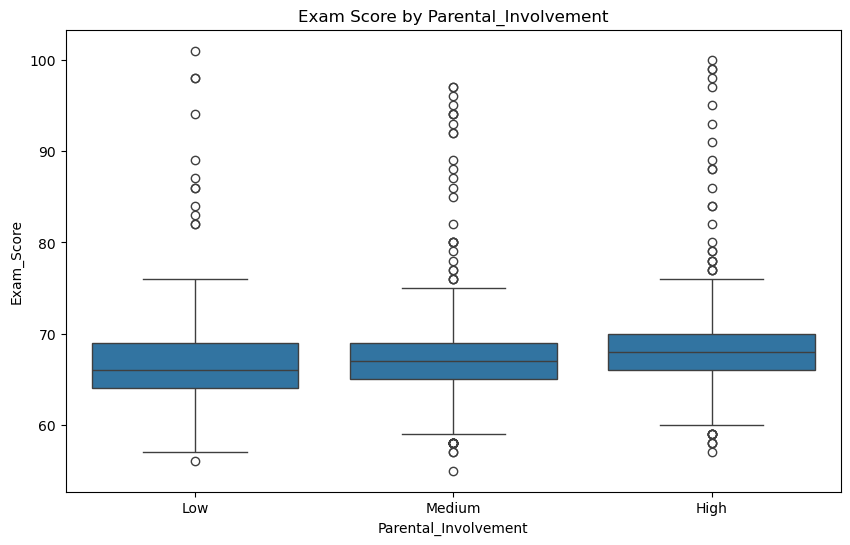

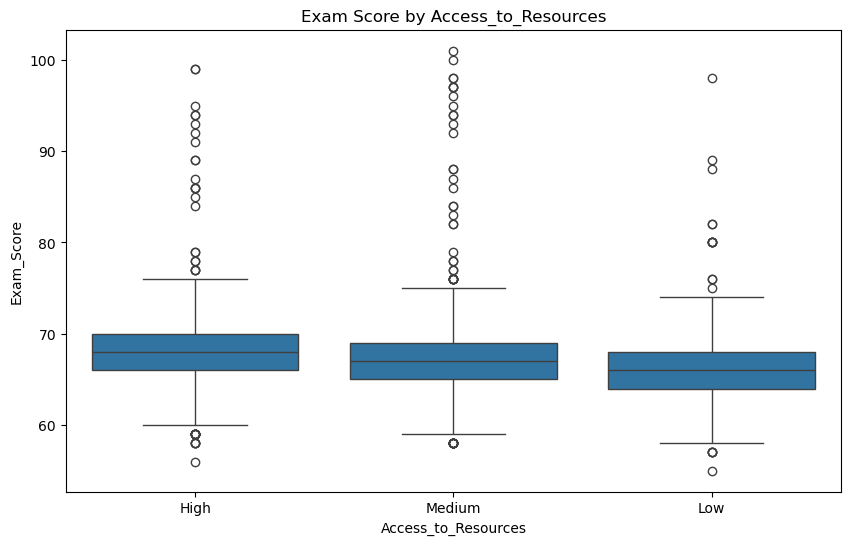

ValueError: Could not interpret value `Extracurricular_Activities` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [8]:
# See how Exam_Score varies by category
for i in cat_col:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=i, y='Exam_Score')
    plt.title('Exam Score by '+ i)
    plt.show()


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Hours_Studied          6607 non-null   int64 
 1   Attendance             6607 non-null   int64 
 2   Parental_Involvement   6607 non-null   object
 3   Access_to_Resources    6607 non-null   object
 4   Previous_Scores        6607 non-null   int64 
 5   Internet_Access        6607 non-null   object
 6   Tutoring_Sessions      6607 non-null   int64 
 7   Family_Income          6607 non-null   object
 8   Peer_Influence         6607 non-null   object
 9   Learning_Disabilities  6607 non-null   object
 10  Distance_from_Home     6540 non-null   object
 11  Exam_Score             6607 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 619.5+ KB


In [10]:
df.describe()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,75.070531,1.493719,67.235659
std,5.990594,11.547475,14.399784,1.230570,3.890456
min,1.000000,60.000000,50.000000,0.000000,55.000000
25%,16.000000,70.000000,63.000000,1.000000,65.000000
50%,20.000000,80.000000,75.000000,1.000000,67.000000
75%,24.000000,90.000000,88.000000,2.000000,69.000000
max,44.000000,100.000000,100.000000,8.000000,101.000000


In [11]:
df=df[df['Exam_Score'] <=100]

In [12]:
df=df[df['Hours_Studied'] <= 40]

In [13]:
df.describe()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Exam_Score
count,6604.000000,6604.000000,6604.000000,6604.000000,6604.000000
mean,19.967141,79.975621,75.064506,1.492883,67.228346
std,5.977314,11.546789,14.398835,1.229938,3.866539
min,1.000000,60.000000,50.000000,0.000000,55.000000
25%,16.000000,70.000000,63.000000,1.000000,65.000000
50%,20.000000,80.000000,75.000000,1.000000,67.000000
75%,24.000000,90.000000,88.000000,2.000000,69.000000
max,39.000000,100.000000,100.000000,8.000000,100.000000


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, SGDRegressor, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer

In [15]:
x = df.drop('Exam_Score',axis=1)
y = df['Exam_Score']

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [17]:
lr =LinearRegression()
el = ElasticNet()
sgd = SGDRegressor()
ridge= Ridge()
lasso = Lasso()
dt = DecisionTreeRegressor()
poly = PolynomialFeatures(degree=1)

In [18]:
num_col = ['Hours_Studied','Attendance','Previous_Scores','Tutoring_Sessions','Exam_Score']
cat_col = ['Parental_Involvement','Access_to_Resources','Internet_Access','Family_Income','Peer_Influence','Learning_Disabilities','Distance_from_Home']
ordinal_col = ['Parental_Involvement','Access_to_Resources','Family_Income','Peer_Influence','Distance_from_Home']
ohe_col = ['Internet_Access','Learning_Disabilities']
from sklearn.model_selection import GridSearchCV
params_lr = {
    'fit_intercept': [True, False],
    'positive': [True,False]
}
grid_lr = GridSearchCV(lr,params_lr, cv=5,scoring='r2')

param_ridge = {
    'alpha': [0.01,0.1,0.02,0.2,0.03,0.3],
    'solver': ['auto','svd','lsqr']
}
grid_ridge = GridSearchCV(ridge,param_ridge,cv=5,scoring='r2')

param_lasso = {
    'alpha': [0.001,0.01,0.1,0.02,0.2]
}
grid_lasso = GridSearchCV(lasso,param_lasso,cv=5,scoring='r2')

param_el = {
    'alpha': [0.001,0.01,0.1,0.002,0.2],
    'l1_ratio':[0.2,0.5,0.8]
}
grid_el = GridSearchCV(el,param_el,cv=5,scoring='r2')

param_sgd = {
    'loss': ['huber', 'squared_error'],   
    'penalty': ['l2', 'elasticnet'],      
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['optimal'],
    'max_iter': [1000, 2000],
    'epsilon': [0.1, 0.5]   
}
grid_sgd = GridSearchCV(sgd,param_sgd,cv=5,scoring='r2')
param_dt = {
    'max_depth': [3,5,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,5],
    'max_features':['sqrt','log2',None]
}
grid_dt = GridSearchCV(dt,param_dt,cv=5,scoring='r2')


 # Physical_Activity, Sleep_Hours, Motivation_Level, Gender,Parental_Education_Level, School_Type,Teacher_Quality, Extracurricular_Activities

In [19]:
df.sample()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Previous_Scores,Internet_Access,Tutoring_Sessions,Family_Income,Peer_Influence,Learning_Disabilities,Distance_from_Home,Exam_Score
3865,16,84,Medium,Medium,65,Yes,1,High,Negative,No,Moderate,65


In [20]:
df['Distance_from_Home'].unique()

array(['Near', 'Moderate', 'Far', nan], dtype=object)

In [21]:
num_col = ['Hours_Studied','Attendance','Previous_Scores','Tutoring_Sessions']

ordinal_col = ['Parental_Involvement','Access_to_Resources','Family_Income','Peer_Influence','Distance_from_Home']

ohe_col = ['Internet_Access','Learning_Disabilities']
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Low','Medium','High'],
        ['Low','Medium','High'],
        ['Low','Medium','High'],
        ['Negative','Neutral','Positive'],
        ['Near','Moderate','Far']
    ]))
])

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

transform = ColumnTransformer([
    ('num', StandardScaler(), num_col),

    ('ord', ordinal_pipeline, ordinal_col),

    ('ohe', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), ohe_col)

], remainder='passthrough')

In [46]:
from sklearn.ensemble import HistGradientBoostingRegressor


df_clean = df.copy()
df_clean = df_clean[(df_clean['Exam_Score'] >= 55) & (df_clean['Exam_Score'] <= 95)] # Drop the crazy 100s and 40s

x = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


pipe = Pipeline([
    ('pre', transform),
    ('model',grid_lr)
])

pipe.fit(x_train, y_train)
print(f"New R2 Score: {pipe.score(x_test, y_test):.4f}")


New R2 Score: 0.8005


In [47]:
y_pred=pipe.predict(x_test)

In [48]:
r2_score(y_test,y_pred)

0.8004506118062399

In [38]:
x_test.sample()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Previous_Scores,Internet_Access,Tutoring_Sessions,Family_Income,Peer_Influence,Learning_Disabilities,Distance_from_Home
3416,25,89,Medium,Low,59,Yes,2,Low,Neutral,No,Near


In [49]:
pipe.predict(pd.DataFrame([[25,89,'Medium','Low',59,'Yes',2,'Low','Neutral','No','Near']],columns=['Hours_Studied','Attendance','Parental_Involvement','Access_to_Resources','Previous_Scores','Internet_Access','Tutoring_Sessions','Family_Income','Peer_Influence','Learning_Disabilities','Distance_from_Home']))

array([68.66500291])

In [50]:
pkl.dump(pipe,open('final_model.pkl','wb'))

In [51]:
df.to_csv('final_df.csv')

In [ ]:
import sklearn
print(sklearn.__version__)